# Regression Model

Goal:

- Predict PEI Index.

Considerations:

- Will Political Scale and State/National Electoral Integrity be included?
- How to deal with missing data?
- Will scaling be used?
- Which metric to use?

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

## Load data and select features

- Start using only 11 sub-indices and no additional features

In [2]:
df = pd.read_csv('data/survey.csv')

# Feature set (the 11 sub-indices without Political Scale or National Electoral Integrity)
index_cols = [
    'Electoral Laws Index', 'Election Procedures Index', 
    'Voting District Boundaries Index', 'Voter Registration Index',
    'Party/Candidate Registration Index', 'Media Coverage Index',
    'Campaign Finance Index', 'Voting Process Index', 
    'Vote Count Index', 'Election Results Index', 
    'Electoral Authorities Index'
]

target = 'Perceptions of Electoral Integrity Index'

# Drop rows where target is missing
model_df = df[index_cols + [target]].dropna(subset=[target])

X = model_df[index_cols]
y = model_df[target]

## Train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows')

Train: 572 rows, Test: 143 rows


## Data transformation

- Median imputation: EDA showed outlires (PEI as low as 9) so stick to median. Low percentage of missingness.
- StandardScaler because Ridge, Lasso and ElasticNet are likely to be used and they penalise coefficient magnitude. If features have different scales, penalty hits them unequally.

In [4]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=index_cols, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=index_cols, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=index_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=index_cols, index=X_test.index)

## Baseline model

- Simplest possible model
- Focus on MAE (since PEI is on a 0-100 scale, it gives a directly interpretable statement)

In [5]:
baseline_pred = np.full(len(y_test), y_train.mean())
print(f'Baseline (predict mean):')
print(f'  R²:   {r2_score(y_test, baseline_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, baseline_pred):.4f}')

Baseline (predict mean):
  R²:   -0.0010
  RMSE: 10.7030
  MAE:  8.7366


## Linear Regression (Indexes Only)

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Cross-validation on training set
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'Linear Regression (5-fold CV):')
print(f'  CV R² mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

# Test set performance
y_pred = lr.predict(X_test_scaled)
print(f'\nTest set:')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred):.4f}')

Linear Regression (5-fold CV):
  CV R² mean: 0.9994 (+/- 0.0002)

Test set:
  R²:   0.9997
  RMSE: 0.1907
  MAE:  0.0563


Extremely high R^2. Nearly perfect -> PEI is a weighted composite of these 11 sub-indices. Model hasn't uncovered what drives integrity perceptions but rather reverse engineered the calculation to create PEI from it's component indices. MAE of 0.056 on a 0-100 scale is also suspicious. CV of 0.0002 also confirms this. It's so deterministic that it doesn't matter what data the model trains on, every fold has the same formula.

This ultimately displays data leakage.

There are 9 standalone Likert items that aren't components of any index. try with these

In [7]:
new_features = ['State Electoral Integrity', 'National Electoral Integrity',
    'Political Scale', 'Election Rigged', 'Deadlines Restrictive', 'Voters Waited',
    'Voters Intimidated', 'Multiple Ballots Cast', 'Machines Accurate',
    'Records Secure', 'Votes Counted Quickly', 'Outcome Reflected Popular Will'
]

In [9]:
likert_map = {
    'Strongly Disagree': 1, 'Disagree': 2,
    'Neither Agree Nor Disagree': 3, 'Agree': 4, 'Strongly Agree': 5,
    "Don't Know": np.nan, 'Not Applicable': np.nan
}

likert_cols = ['Election Rigged', 'Deadlines Restrictive', 'Voters Waited',
               'Voters Intimidated', 'Multiple Ballots Cast', 'Machines Accurate',
               'Records Secure', 'Votes Counted Quickly', 'Outcome Reflected Popular Will']

for col in likert_cols:
    df[col + '_encoded'] = df[col].map(likert_map)

Need to impute 'Don't Know' and 'Not Applicable' as NaN because they don't fit on the agree-disagree scale.

Median imputer will then handle these NaNs. Not an issue as they are all less than 20% missing.

In [10]:
encoded_likert_cols = [col + '_encoded' for col in likert_cols]

Define features (again)

In [11]:
feature_cols = ['State Electoral Integrity', 'National Electoral Integrity', 
                'Political Scale'] + encoded_likert_cols

target = 'Perceptions of Electoral Integrity Index'

model_df = df[feature_cols + [target]].dropna(subset=[target])
X = model_df[feature_cols]
y = model_df[target]

Train/test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows')

Train: 572 rows, Test: 143 rows


Impute and scale

In [13]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=feature_cols, index=X_test.index)

Baseline model

In [14]:
baseline_pred = np.full(len(y_test), y_train.mean())
print(f'Baseline (predict mean):')
print(f'  R²:   {r2_score(y_test, baseline_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, baseline_pred):.4f}')

Baseline (predict mean):
  R²:   -0.0010
  RMSE: 10.7030
  MAE:  8.7366


Linear regression

In [15]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'Linear Regression (5-fold CV):')
print(f'  CV R² mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

y_pred = lr.predict(X_test_scaled)
print(f'\nTest set:')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred):.4f}')

Linear Regression (5-fold CV):
  CV R² mean: 0.6194 (+/- 0.0432)

Test set:
  R²:   0.5962
  RMSE: 6.7982
  MAE:  5.1574


These are much more realistic results. R^2 of 0.6 -> 12 new features explain 60% of variance in PEI. MAE of 5.16 -> On average, predictions are off by about 5 points on a 0-100 scale. Better than the baseline of 8.74. RMSE of 6.80 vs MAE of 5.16 -> gap between these informs us that some predictions are worse than others. Probably the outliers that are visible. CV R^2 of 0.62 +- 0.04 -> stable across folds, s not overfitting to a lucky split. 

Coefficients

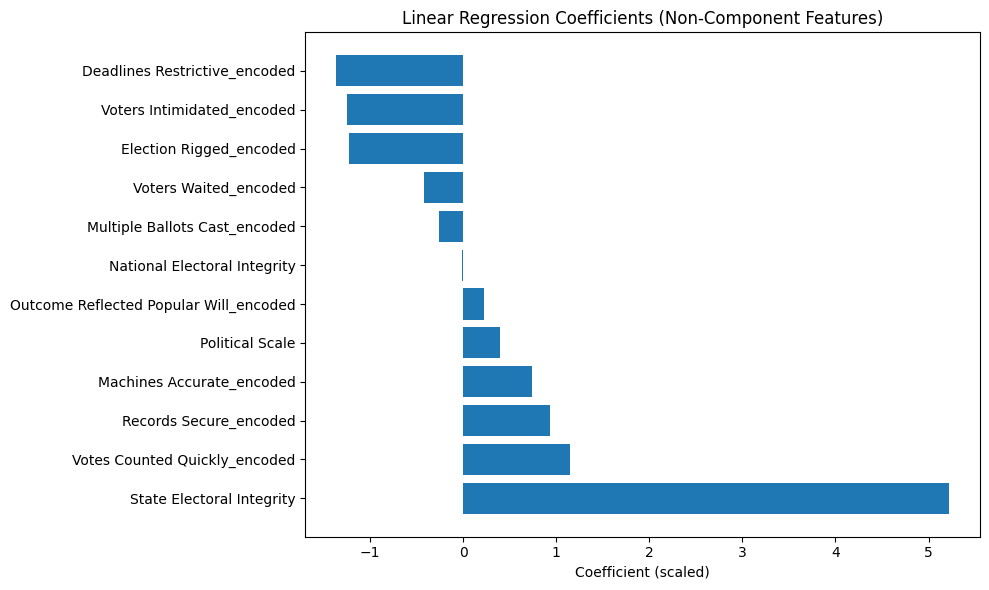

In [16]:
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title('Linear Regression Coefficients (Non-Component Features)')
plt.xlabel('Coefficient (scaled)')
plt.tight_layout()
plt.show()

State Electoral Integrity is the biggest driver by far, however it is asking a similar question to PEI but in a simpler format. So, it's doing a lot of heavy lifting. Worth investigating.

In [17]:
# Experiment: remove State/National Electoral Integrity
feature_cols_no_integrity = ['Political Scale'] + encoded_likert_cols

X_no_integrity = model_df[feature_cols_no_integrity]
X_train_ni, X_test_ni, y_train_ni, y_test_ni = train_test_split(
    X_no_integrity, y, test_size=0.2, random_state=42)

X_train_ni_imp = pd.DataFrame(imputer.fit_transform(X_train_ni), columns=feature_cols_no_integrity, index=X_train_ni.index)
X_test_ni_imp = pd.DataFrame(imputer.transform(X_test_ni), columns=feature_cols_no_integrity, index=X_test_ni.index)

X_train_ni_sc = pd.DataFrame(scaler.fit_transform(X_train_ni_imp), columns=feature_cols_no_integrity, index=X_train_ni.index)
X_test_ni_sc = pd.DataFrame(scaler.transform(X_test_ni_imp), columns=feature_cols_no_integrity, index=X_test_ni.index)

lr_ni = LinearRegression()
lr_ni.fit(X_train_ni_sc, y_train_ni)

cv_ni = cross_val_score(lr_ni, X_train_ni_sc, y_train_ni, cv=5, scoring='r2')
y_pred_ni = lr_ni.predict(X_test_ni_sc)

print(f'Without State/National Electoral Integrity:')
print(f'  CV R²: {cv_ni.mean():.4f} (+/- {cv_ni.std():.4f})')
print(f'  Test R²: {r2_score(y_test_ni, y_pred_ni):.4f}')
print(f'  Test MAE: {mean_absolute_error(y_test_ni, y_pred_ni):.4f}')

Without State/National Electoral Integrity:
  CV R²: 0.4809 (+/- 0.0517)
  Test R²: 0.4135
  Test MAE: 6.1660


R^2 dropped, but standalone Likert items still explain 41% of PEI variance. Comparing the three models so far:

| Model | Features | Test R² | Test MAE |
|---|---|---|---|
| Sub-indices (leaky) | 11 sub-indices | 0.9997 | 0.06 |
| Full non-component | Integrity ratings + Political Scale + 9 Likert | 0.60 | 5.16 |
| Likert only | Political Scale + 9 Likert | 0.41 | 6.17 |

- Sub-indices model confirmed PEI is a deterministic composite (useful finding if not model)
- State/National Electoral Integrity ratings are the strongest single predictor group, but are similar to the target variable.
- Standalone Likert items capture 41% of variance (specific views on election rigging, machine accuracy, voter intimidation, etc. meaningfully predict overall integrity perception)

Feature set moving forward: full non-component (the right balance between performance and leakage).

Next steps: Ridge/Lasso

## Ridge

In [18]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Hyperparameter search for alpha
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2', return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

print(f'Best alpha: {grid_search.best_params_["alpha"]}')
print(f'Best CV R²: {grid_search.best_score_:.4f}')

# Test set performance with best model
best_ridge = grid_search.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

print(f'\nRidge Regression (alpha={grid_search.best_params_["alpha"]}):')
print(f'  Test R²:   {r2_score(y_test, y_pred_ridge):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}')
print(f'  Test MAE:  {mean_absolute_error(y_test, y_pred_ridge):.4f}')

# Compare coefficients: Linear vs Ridge
coef_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Linear': lr.coef_,
    'Ridge': best_ridge.coef_
})

coef_comparison['Difference'] = abs(coef_comparison['Linear']) - abs(coef_comparison['Ridge'])
print(f'\nCoefficient comparison:')
print(coef_comparison.sort_values('Difference', ascending=False).to_string(index=False))

Best alpha: 10
Best CV R²: 0.6202

Ridge Regression (alpha=10):
  Test R²:   0.5951
  Test RMSE: 6.8071
  Test MAE:  5.1683

Coefficient comparison:
                               Feature    Linear     Ridge  Difference
             State Electoral Integrity  5.223399  5.082052    0.141348
                       Political Scale  0.392991  0.380538    0.012453
            Voters Intimidated_encoded -1.245964 -1.234451    0.011513
         Votes Counted Quickly_encoded  1.146519  1.147581   -0.001062
         Deadlines Restrictive_encoded -1.364965 -1.366741   -0.001777
               Election Rigged_encoded -1.228829 -1.231337   -0.002508
         Multiple Ballots Cast_encoded -0.260358 -0.264239   -0.003881
                Records Secure_encoded  0.935402  0.939376   -0.003973
Outcome Reflected Popular Will_encoded  0.221622  0.232566   -0.010944
                 Voters Waited_encoded -0.416055 -0.431749   -0.015694
             Machines Accurate_encoded  0.738499  0.757840   -0.019341

R^2 is nearly identical to linear regression. Mulricollinearity therefore isn't a significant problem and Ridge had nothing to fix. The coefficients were already stable, so shrinking thrm did nothing to help. Consistent with EDA finding that index correlations were mostly below 0.5.

## Lasso

In [19]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='r2')
grid_search_lasso.fit(X_train_scaled, y_train)

print(f'Best alpha: {grid_search_lasso.best_params_["alpha"]}')
print(f'Best CV R²: {grid_search_lasso.best_score_:.4f}')

best_lasso = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)

print(f'\nLasso Regression (alpha={grid_search_lasso.best_params_["alpha"]}):')
print(f'  Test R²:   {r2_score(y_test, y_pred_lasso):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}')
print(f'  Test MAE:  {mean_absolute_error(y_test, y_pred_lasso):.4f}')

# Show which features Lasso kept vs eliminated
lasso_coef = pd.DataFrame({'Feature': feature_cols, 'Coefficient': best_lasso.coef_})
lasso_coef['Kept'] = lasso_coef['Coefficient'] != 0
print(f'\nFeatures kept: {lasso_coef["Kept"].sum()}/{len(feature_cols)}')
print(lasso_coef.sort_values('Coefficient', ascending=False).to_string(index=False))

Best alpha: 0.1
Best CV R²: 0.6207

Lasso Regression (alpha=0.1):
  Test R²:   0.5949
  Test RMSE: 6.8088
  Test MAE:  5.1739

Features kept: 11/12
                               Feature  Coefficient  Kept
             State Electoral Integrity     5.217128  True
         Votes Counted Quickly_encoded     1.101139  True
                Records Secure_encoded     0.916697  True
             Machines Accurate_encoded     0.733068  True
                       Political Scale     0.304521  True
Outcome Reflected Popular Will_encoded     0.188029  True
          National Electoral Integrity     0.000000 False
         Multiple Ballots Cast_encoded    -0.166313  True
                 Voters Waited_encoded    -0.365592  True
               Election Rigged_encoded    -1.197384  True
            Voters Intimidated_encoded    -1.223898  True
         Deadlines Restrictive_encoded    -1.335527  True


Only National Electoral Integrity got eliminated. Data doesn't benefit from regularisation. Coefficient ranking is stable across all models.

In [20]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(max_iter=10000)
param_grid_elastic = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search_elastic = GridSearchCV(elastic, param_grid_elastic, cv=5, scoring='r2')
grid_search_elastic.fit(X_train_scaled, y_train)

print(f'Best alpha: {grid_search_elastic.best_params_["alpha"]}')
print(f'Best l1_ratio: {grid_search_elastic.best_params_["l1_ratio"]}')
print(f'Best CV R²: {grid_search_elastic.best_score_:.4f}')

best_elastic = grid_search_elastic.best_estimator_
y_pred_elastic = best_elastic.predict(X_test_scaled)

print(f'\nElastic Net:')
print(f'  Test R²:   {r2_score(y_test, y_pred_elastic):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_elastic)):.4f}')
print(f'  Test MAE:  {mean_absolute_error(y_test, y_pred_elastic):.4f}')

# Features kept
elastic_coef = pd.DataFrame({'Feature': feature_cols, 'Coefficient': best_elastic.coef_})
elastic_coef['Kept'] = elastic_coef['Coefficient'] != 0
print(f'\nFeatures kept: {elastic_coef["Kept"].sum()}/{len(feature_cols)}')
print(elastic_coef.sort_values('Coefficient', ascending=False).to_string(index=False))

Best alpha: 0.1
Best l1_ratio: 0.3
Best CV R²: 0.6211

Elastic Net:
  Test R²:   0.5913
  Test RMSE: 6.8391
  Test MAE:  5.2007

Features kept: 12/12
                               Feature  Coefficient  Kept
             State Electoral Integrity     4.715497  True
         Votes Counted Quickly_encoded     1.132433  True
                Records Secure_encoded     0.946880  True
             Machines Accurate_encoded     0.803241  True
                       Political Scale     0.329381  True
Outcome Reflected Popular Will_encoded     0.254476  True
          National Electoral Integrity     0.214750  True
         Multiple Ballots Cast_encoded    -0.247449  True
                 Voters Waited_encoded    -0.455247  True
            Voters Intimidated_encoded    -1.198677  True
               Election Rigged_encoded    -1.227658  True
         Deadlines Restrictive_encoded    -1.356331  True


Also no meaningful difference after using Elastic Net. All linear models plateau at 0.60. Any remaining signal is probably non-linear. The l1_ratio leaning toward Ridge and retaining all features suggests no features are truly redundant (though National Electoral Integrity is borderline)

| Model | Alpha | l1_ratio | Features Kept | Test R² | Test RMSE | Test MAE |
|---|---|---|---|---|---|---|
| Baseline (mean) | - | - | - | -0.001 | 10.703 | 8.737 |
| Linear Regression | - | - | 12 | 0.596 | 6.798 | 5.157 |
| Ridge | 10 | - | 12 | 0.595 | 6.807 | 5.168 |
| Lasso | 0.1 | - | 11 | 0.595 | 6.809 | 5.174 |
| Elastic Net | 0.1 | 0.3 | 12 | 0.591 | 6.839 | 5.201 |

Try a tree-based modelnext to see if this captures any more signal.

## Random Forest

Best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best CV R²: 0.6163

Random Forest:
  Test R²:   0.6190
  Test RMSE: 6.6030
  Test MAE:  5.1301


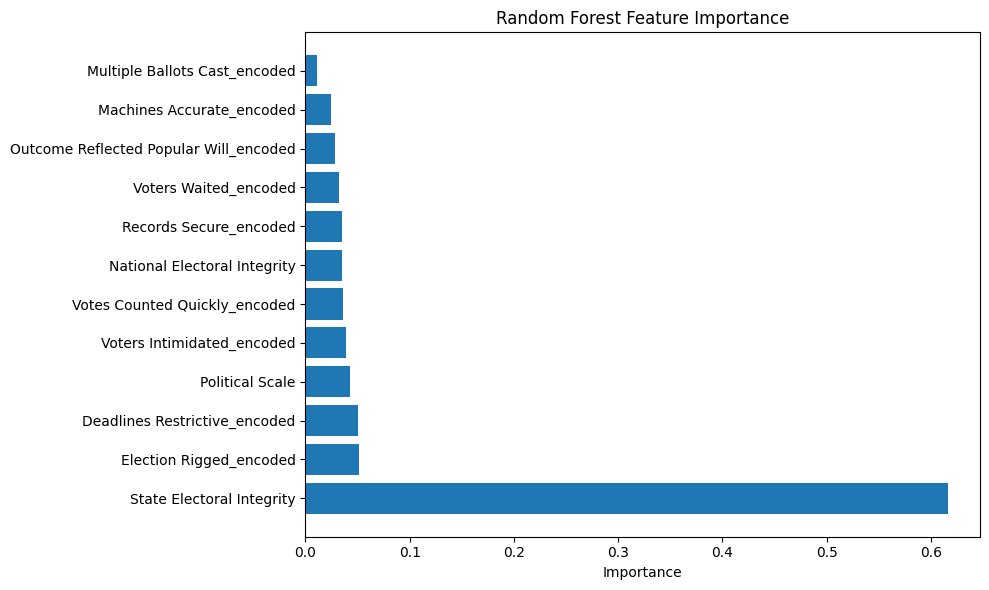

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Hyperparameter search
rf = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

print(f'Best params: {grid_search_rf.best_params_}')
print(f'Best CV R²: {grid_search_rf.best_score_:.4f}')

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print(f'\nRandom Forest:')
print(f'  Test R²:   {r2_score(y_test, y_pred_rf):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')
print(f'  Test MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}')

# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

(RF doesn't technically need scaling but do it for fairness sake across models)

There is a marginal improvement in R^2 (0.596 for Linear and 0.619 for RF. MAE went from 5.16 to 5.13.) Non-linear signal exists but it's small.

- max_depth=None -> trees grew fully. Data has enough signal to justify deep splits without overfitting.

State Electoral Integrity dominates feature importance in both linear coefficients and Random Forest importance, confirming it is the single strongest predictor of PEI regardless of model type. This suggests the relationship between features and PEI is predominantly linear, which explains the small gap between OLs and RF.

## XGBoost

In [23]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train)

print(f'Best params: {grid_search_xgb.best_params_}')
print(f'Best CV R²: {grid_search_xgb.best_score_:.4f}')

best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)

print(f'\nXGBoost:')
print(f'  Test R²:   {r2_score(y_test, y_pred_xgb):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}')
print(f'  Test MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}')

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R²: 0.6145

XGBoost:
  Test R²:   0.6503
  Test RMSE: 6.3263
  Test MAE:  4.9170


R^2 is 0.65, beat the former plateau of 0.60. While linear regression is more interpretable, XGBoost improves performance enough that this will be proceeded with.

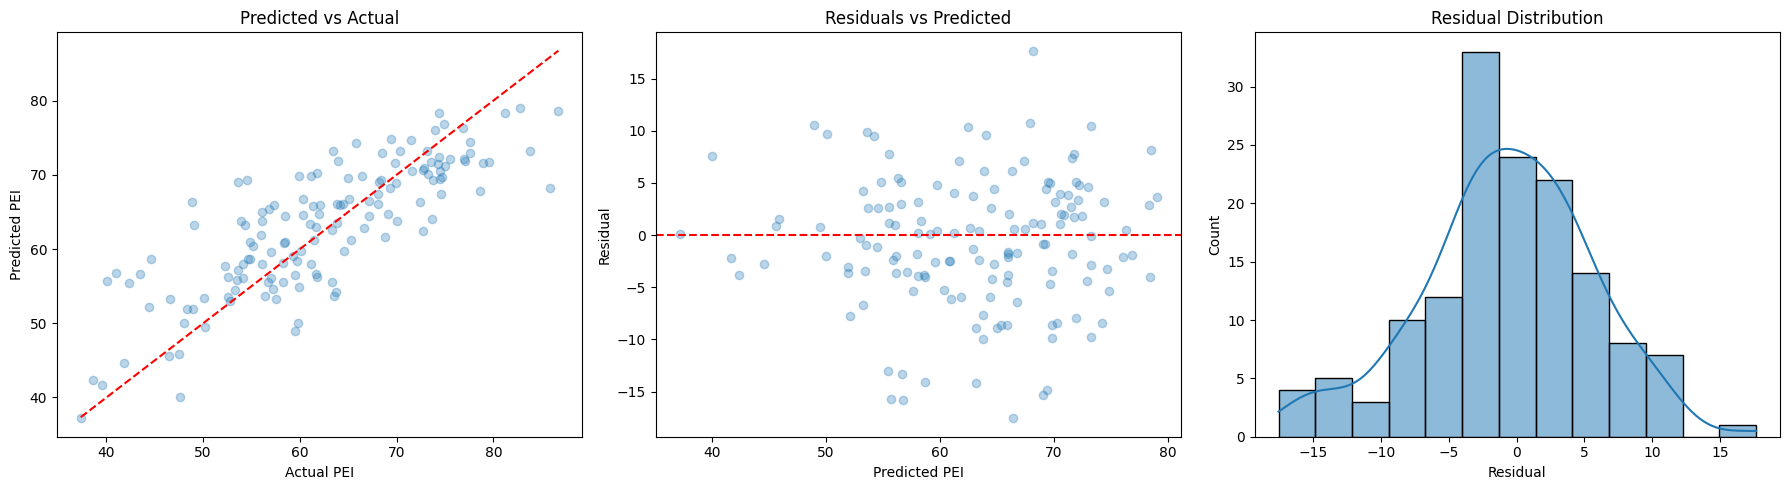

Residual mean: -0.7678
Residual std: 6.3016


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_xgb, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual PEI')
axes[0].set_ylabel('Predicted PEI')
axes[0].set_title('Predicted vs Actual')

# Residuals vs Predicted
residuals = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals, alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted PEI')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

# Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_xlabel('Residual')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print(f'Residual mean: {residuals.mean():.4f}')
print(f'Residual std: {residuals.std():.4f}')


- Predicted vs actual: cluster around the identity line, so captures the general trend. Some scatter in the mid range and underprediction towards the high end. Suggests model struggles to predict extreme values (common for tree-based ensemble methods)

- Residuals vs predicted: Residuals are roughly centered around zero, except there is some heteroscedasticity (spread wider at lower predicted values compared to middle range). No obvious curvilinear pattern -> no non-linear relationship that is being missed so feature engineering may not be the most useful next step.

- Residual distribution: Roughly normal but some left-skew so model occasionally overpredicts.

decent but not fantastic fit. Covers broad pattern but some prediction error.

## Model Selection

XGBoost achieves the best performance (R^2 0.65, MAE 4.92) although Linear Regression 
is close (R^2 0.60, MAE 5.16). Choose XGBoost for the pipeline as the 5% R^2 
improvement is meaningful on a 0-100 scale, and the residual analysis confirms 
it generalises fairly well (despite minor heteroscedasticity at lower PEI values).

The underprediction at extreme values is a known limitation. The 5 outlier experts 
(PEI 9-29) identified in EDA probably account for much of this. With only 5 cases, 
no model can reliably learn their pattern.

## Critical Reflection

- The performance ceiling (0.60-0.65) reflects the feature set limitation not model failure.

- State Electoral Integrity dominates all models. Regression is heavily dependent on a single feature that is close to the target.

- Heterscedasticity suggests the model is less reliable for experts who think integrity is poor (the cases that are the most interesting in this problem).

Save model's details for the pipeline:

In [25]:
print(f'Selected model: XGBoost')
print(f'Params: {grid_search_xgb.best_params_}')
print(f'Features: {feature_cols}')
print(f'Preprocessing: MedianImputer -> StandardScaler')

Selected model: XGBoost
Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Features: ['State Electoral Integrity', 'National Electoral Integrity', 'Political Scale', 'Election Rigged_encoded', 'Deadlines Restrictive_encoded', 'Voters Waited_encoded', 'Voters Intimidated_encoded', 'Multiple Ballots Cast_encoded', 'Machines Accurate_encoded', 'Records Secure_encoded', 'Votes Counted Quickly_encoded', 'Outcome Reflected Popular Will_encoded']
Preprocessing: MedianImputer -> StandardScaler
